# Importar librerías

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

In [2]:
import warnings
warnings.filterwarnings("ignore")

# EDA

Los Datos fueron generados a través de un sistema de simulación, automatizado para que el código quede mas limpio. Para más información revisar `data-science\src\generar_dataset_perfiles.py`

In [3]:
df = pd.read_csv("perfiles_simulados.csv")
df

,Ingreso_Mensual,Proporcion_Gasto,Gasto_Total,Nivel_Endeudamiento,Frecuencia_Ahorro,Perfil_Financiero
0,20968.73,86.58,18154.54,37.45,Media,Saludable
1,109240.09,42.20,46102.73,95.07,Baja,En Riesgo
2,65370.96,76.10,49749.30,73.20,Baja,En Riesgo
3,100837.78,78.54,79195.17,59.87,Baja,En Riesgo
4,44921.24,63.93,28718.35,15.60,Media,Saludable
...,...,...,...,...,...,...
395,105880.18,99.72,105586.83,93.08,Media,En Riesgo
396,112504.64,107.88,121369.01,85.84,Baja,En Riesgo
397,71982.88,107.51,77388.95,42.90,Baja,En Riesgo
398,86504.79,89.97,77830.22,75.09,Baja,En Riesgo


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ingreso_Mensual      400 non-null    float64
 1   Proporcion_Gasto     400 non-null    float64
 2   Gasto_Total          400 non-null    float64
 3   Nivel_Endeudamiento  400 non-null    float64
 4   Frecuencia_Ahorro    400 non-null    object 
 5   Perfil_Financiero    400 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.9+ KB


In [5]:
print(f"Datos únicos: {df.count().unique()}\n")
print(f"Tipo de datos: \n{df.dtypes}\n")
print(f"Datos nulos: \n{df.count().isnull()}\n")

df.describe()

Datos únicos: [400]

Tipo de datos: 
Ingreso_Mensual        float64
Proporcion_Gasto       float64
Gasto_Total            float64
Nivel_Endeudamiento    float64
Frecuencia_Ahorro       object
Perfil_Financiero       object
dtype: object

Datos nulos: 
Ingreso_Mensual        False
Proporcion_Gasto       False
Gasto_Total            False
Nivel_Endeudamiento    False
Frecuencia_Ahorro      False
Perfil_Financiero      False
dtype: bool



,Ingreso_Mensual,Proporcion_Gasto,Gasto_Total,Nivel_Endeudamiento
count,400.000000,400.000000,400.000000,400.000000
mean,64760.300525,70.284300,45894.790700,49.419250
std,32440.720735,23.746632,29548.280598,29.375659
min,10778.670000,30.370000,3567.530000,0.510000
25%,36285.900000,48.612500,22008.152500,24.132500
50%,65129.855000,71.510000,38142.905000,51.170000
75%,93560.250000,91.162500,63986.050000,74.752500
max,119968.830000,109.830000,130098.750000,99.050000


# Ingeniería de atributos

In [6]:
df["ratio_gasto_ingreso"] = df["Gasto_Total"] / df["Ingreso_Mensual"]
df["ratio_gasto_ingreso"]

,ratio_gasto_ingreso
0,0.865791
1,0.422031
2,0.761031
3,0.785372
4,0.639304
...,...
395,0.997229
396,1.078791
397,1.075102
398,0.899722


Ordinal Encoding para `frecuencia_ahorro`, ya que `Baja<Media<Alta` tiene un orden lógico


In [7]:
ordinal_encoder = OrdinalEncoder(categories=[["Baja", "Media", "Alta"]])
df["frecuencia_ahorro_encoded"] = ordinal_encoder.fit_transform(
    df[["Frecuencia_Ahorro"]]
)
df["frecuencia_ahorro_encoded"]

,frecuencia_ahorro_encoded
0,1.0
1,0.0
2,0.0
3,0.0
4,1.0
...,...
395,1.0
396,0.0
397,0.0
398,0.0


# Visualizaciones

#### Conteo de Perfiles Financieros

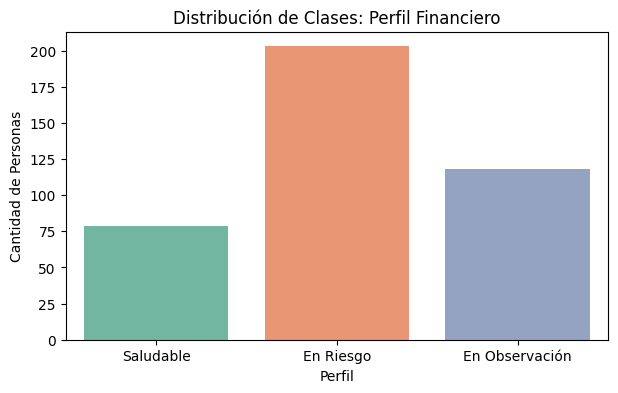

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Perfil_Financiero", palette="Set2")
plt.title("Distribución de Clases: Perfil Financiero")
plt.xlabel("Perfil")
plt.ylabel("Cantidad de Personas")
plt.show()

#### Diagrama de Dispersión: Endeudamiento vs Ratio Gasto/Ingreso

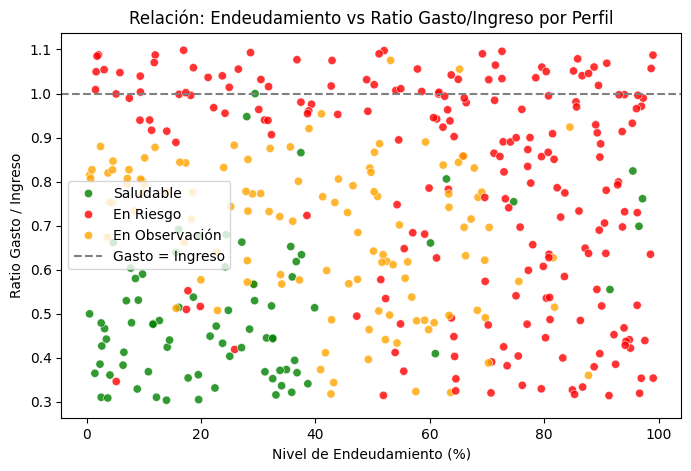

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Nivel_Endeudamiento",
    y="ratio_gasto_ingreso",
    hue="Perfil_Financiero",
    palette={"Saludable": "green", "En Observación": "orange", "En Riesgo": "red"},
    alpha=0.8,
)
plt.title("Relación: Endeudamiento vs Ratio Gasto/Ingreso por Perfil")
plt.xlabel("Nivel de Endeudamiento (%)")
plt.ylabel("Ratio Gasto / Ingreso")
plt.axhline(1.0, color="gray", linestyle="--", label="Gasto = Ingreso")
plt.legend()
plt.show()

#### Matriz de Correlación

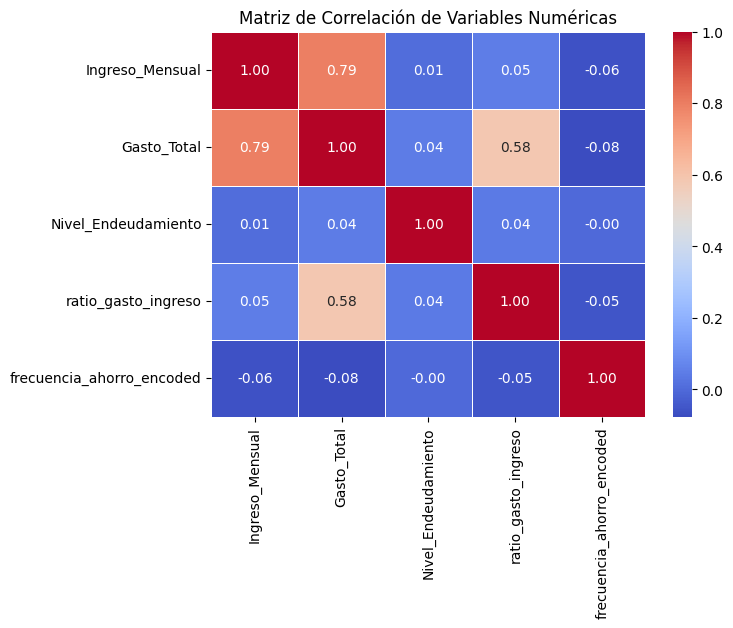

In [10]:
plt.figure(figsize=(7, 5))
numeric_cols = [
    "Ingreso_Mensual",
    "Gasto_Total",
    "Nivel_Endeudamiento",
    "ratio_gasto_ingreso",
    "frecuencia_ahorro_encoded",
]
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

#### Distribución de Frecuencia de Ahorro según Perfil

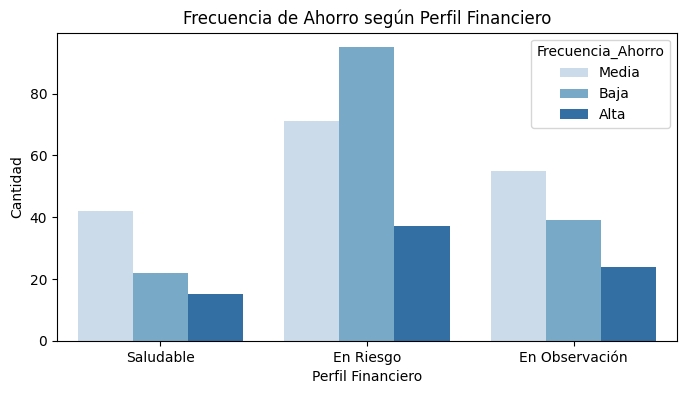

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Perfil_Financiero", hue="Frecuencia_Ahorro", palette="Blues")
plt.title("Frecuencia de Ahorro según Perfil Financiero")
plt.xlabel("Perfil Financiero")
plt.ylabel("Cantidad")
plt.show()

# Guarda el `CSV` procesado

In [12]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "perfiles_procesados.csv"

df.to_csv(output_path, sep=",", encoding="utf-8", index=False)

# Modelo de perfil financiero

# Entrenamiento de los modelos de clasificación

Una vez finalizado el análisis exploratorio y la ingeniería de atributos, se procede al entrenamiento de los modelos de Machine Learning.

Para esta etapa se utilizarán tres algoritmos de clasificación supervisada:

- Regresión Logística
- Árbol de Decisión
- Random Forest

Cada uno presenta características distintas. La Regresión Logística requiere que las variables numéricas se encuentren escaladas, mientras que los modelos basados en árboles son capaces de trabajar directamente con los datos originales.



## Preprocesamiento mediante ColumnTransformer

Los algoritmos de Machine Learning requieren que todas las variables de entrada sean numéricas. Sin embargo, algunas variables del conjunto de datos, como **frecuencia_ahorro**, son de tipo categórico.

Para automatizar este proceso se utilizará **ColumnTransformer**, una herramienta de Scikit-Learn que permite aplicar diferentes transformaciones dependiendo del tipo de variable.

En este proyecto se realizarán las siguientes transformaciones:

- Las variables numéricas serán estandarizadas mediante **StandardScaler** para los modelos que lo requieran.
- La variable **frecuencia_ahorro** será transformada mediante **OrdinalEncoder**, respetando el orden natural de sus categorías (Baja < Media < Alta).

Al integrar estas transformaciones dentro de un **Pipeline**, se evita la fuga de información (Data Leakage) y se garantiza que el mismo procesamiento se aplique durante el entrenamiento, la validación cruzada y la predicción.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Variables numéricas
numeric_features = [
    "Ingreso_Mensual",
    "Proporcion_Gasto",
    "Gasto_Total",
    "Nivel_Endeudamiento"
]

# Variables categóricas
categorical_features = [
    "Frecuencia_Ahorro"
]

# Preprocesador para modelos lineales
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OrdinalEncoder(
                categories=[["Baja", "Media", "Alta"]]
            ),
            categorical_features
        )
    ]
)

# Preprocesador para modelos basados en árboles
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                categories=[["Baja", "Media", "Alta"]]
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Regresión Logística

Este algoritmo requiere que las variables numéricas se encuentren en una escala similar para obtener un mejor desempeño.



## Árbol de Decisión

Los árboles de decisión generan reglas de clasificación a partir de divisiones sucesivas sobre las variables predictoras.

Debido a su naturaleza, este algoritmo no requiere que los datos se encuentren escalados.

## Random Forest

Random Forest es un método de ensamble basado en múltiples árboles de decisión.

Cada árbol es entrenado sobre una muestra diferente del conjunto de datos y el resultado final corresponde a la votación de todos ellos, lo que generalmente produce modelos más robustos y con mejor capacidad de generalización.

## Construcción de los Pipelines

Cada algoritmo utilizará un Pipeline independiente.

La Regresión Logística requiere tanto el escalamiento de las variables numéricas como la codificación de las variables categóricas.

Por otro lado, los modelos basados en árboles no necesitan escalamiento, aunque sí requieren que todas las variables sean numéricas. Por esta razón únicamente se aplica la codificación ordinal antes del entrenamiento.

In [14]:
models = {

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("classifier",
         LogisticRegression(
             max_iter=1000,
             random_state=42
         ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("classifier",
         DecisionTreeClassifier(
             random_state=42,
             max_depth=5
         ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("classifier",
         RandomForestClassifier(
             n_estimators=200,
             random_state=42
         ))
    ])

}

## Separacion de los datos de entrenamiento y prueba

In [15]:
# Variables predictoras y variable objetivo
X = df.drop(columns="Perfil_Financiero")
y = df["Perfil_Financiero"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

##Stratified KFold

Para obtener una estimación más robusta del desempeño de cada algoritmo se emplea validación cruzada estratificada de cinco particiones. En cada iteración el modelo es entrenado utilizando una combinación distinta de los datos y posteriormente evaluado sobre el subconjunto restante. Finalmente se calcula el promedio de las métricas obtenidas.

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro"
        ]
    )

    cv_results.append({
        "Modelo": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall": scores["test_recall_macro"].mean(),
        "F1-Score": scores["test_f1_macro"].mean()
    })

results_cv = pd.DataFrame(cv_results)

results_cv = results_cv.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_cv

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.89375,0.906327,0.866191,0.880700
1,Decision Tree,0.83125,0.817125,0.809268,0.810341
2,Logistic Regression,0.73125,0.744444,0.699438,0.704740


Elegimos el mejor modelo de los resultados anteriores

In [19]:
best_model_name = results_cv.iloc[0]["Modelo"]

best_model = models[best_model_name]

print("El mejor modelo es:", best_model_name)

El mejor modelo es: Random Forest


Se entrena el modelo ganador utilizando los datos de Train

In [20]:
best_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OrdinalEncoder(categories=[['Baja',
                                                                              'Media',
                                                                              'Alta']]),
                                                  ['Frecuencia_Ahorro'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [21]:
y_pred = best_model.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

En Observación       0.87      0.87      0.87        23
     En Riesgo       0.93      0.93      0.93        41
     Saludable       1.00      1.00      1.00        16

      accuracy                           0.93        80
     macro avg       0.93      0.93      0.93        80
  weighted avg       0.93      0.93      0.93        80



## Interpretación de los resultados

El modelo seleccionado obtuvo un **Accuracy del 93%** sobre el conjunto de prueba, lo que indica que fue capaz de clasificar correctamente la mayoría de los perfiles financieros simulados que no participaron durante el entrenamiento.

Las métricas de **Precision**, **Recall** y **F1-Score** presentan valores cercanos o superiores al 0.90 para la mayoría de las clases, lo que refleja un desempeño consistente y un buen equilibrio entre la capacidad del modelo para identificar correctamente cada perfil financiero y minimizar las clasificaciones erróneas.

En conjunto, los resultados muestran que el modelo posee una adecuada capacidad de generalización sobre los datos simulados y constituye una herramienta confiable para la clasificación automática del perfil financiero.

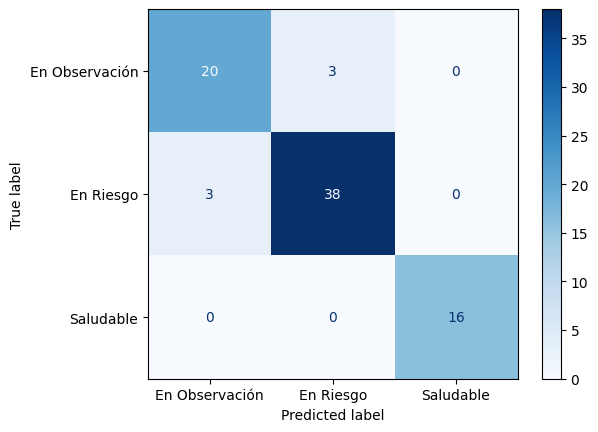

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.show()